#  Problem Statement

Understanding human emotions from data is challenging because communication involves **multiple modalities like text and images**.

Traditional approaches use **single modality**:
- Text → misses visual context  
- Images → lack detailed meaning  

These methods fail to capture the **full emotional context**.

---

##  Problem

**How can we effectively combine text and image data to improve depression/sentiment detection?**

---

##  Objective

To build a **multimodal depression detection system** that:

- Uses strong text models:
  - **RoBERTa + BiGRU**
  - **BERT + BiGRU + Attention**
  - **DistilBERT + BiGRU**
- Uses image model:
  - **ResNet18**
- Combines both using **fusion techniques**

---

#  Proposed Approach

We design a **multimodal deep learning system** that:

- Extracts features from text and images  
- Combines them using fusion strategies  
- Improves performance over single models  

---

#  Project Pipeline

##  1. Data Collection

- Dataset contains:
  - **Text data**
  - **Image data**
- Labels: **Depression (1) / Non-Depression (0)**  

---

##  2. Data Preprocessing

###  Text
- Cleaning and normalization  
- Tokenization using:
  - RoBERTa  
  - BERT  
  - DistilBERT  

---

###  Image
- Resize to **224×224**  
- Normalization (ImageNet standard)  
- Data augmentation:
  - Flip  
  - Rotation  
  - Color jitter  

---

##  3. Feature Extraction

| Modality | Model | Output |
|----------|------|--------|
| Text | RoBERTa / BERT / DistilBERT + BiGRU | Contextual features |
| Image | ResNet18 | Visual features |

---

##  4. Fusion Strategies

Different ways to combine text + image:

- **Add Fusion**  
- **Concat Fusion**  
- **Attention Fusion**  
- **Concat + Attention (Best)**  
- **Bilinear Fusion**  
- **Cross Residual Fusion**  

---

##  5. Model Architecture

- **Text Encoder**
  - Transformer + BiGRU  

- **Image Encoder**
  - ResNet18  

- **Fusion Layer**
  - Combines text + image features  

- **Classifier**
  - Fully connected layer  

---

##  6. Training

- Loss: **CrossEntropyLoss**  
- Optimizer: **AdamW**  
- Techniques:
  - Dropout  
  - Gradient clipping  
  - Early stopping  
  - Learning rate scheduler  
  - Mixed precision training  

---

##  7. Evaluation

- Accuracy  
- Precision  
- Recall  
- F1 Score  
- ROC-AUC  

Additional:
- Confusion Matrix  
- ROC Curve  

---

#  Final Outcome

- Text models achieved **~98% performance**  
- Multimodal model (best: concat_attention) achieved **~95%**  
- Image-only model achieved **~87%**

---

#  Key Insight

- **Text is the strongest modality**  
- Multimodal improves over image-only  
- Best fusion = **Concat + Attention**  

---

#  Pipeline Summary

```text
Text + Image
      ↓
Preprocessing
      ↓
Feature Extraction
      ↓
Fusion (Attention / Concat / etc.)
      ↓
Classifier
      ↓
Depression Prediction

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
from transformers import BertTokenizer, RobertaTokenizer, DistilBertTokenizer
from transformers import RobertaModel
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, f1_score

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
from transformers import BertTokenizer, RobertaTokenizer, DistilBertTokenizer
from transformers import RobertaModel
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, f1_score

from collections import Counter

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

# TEXT ANALYSIS AND MODELLING

# Data Cleaning and Data Preprocessing

# Loading Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/infamouscoder/depression-reddit-cleaned/depression_dataset_reddit_cleaned.csv")
df.head()


,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


# Before Preprocessing EDA

In [86]:
df.shape

(7731, 2)

In [87]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7731 entries, 0 to 7730
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_text     7731 non-null   object
 1   is_depression  7731 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 120.9+ KB
None
clean_text       0
is_depression    0
dtype: int64


## Class Distribution

In [3]:
df["is_depression"].value_counts()

is_depression
0    3900
1    3831
Name: count, dtype: int64

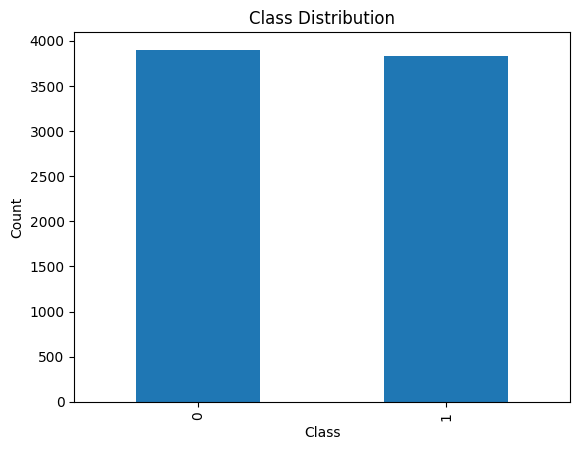

In [4]:
df["is_depression"].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

###  Inference

* The dataset is **balanced**, with nearly equal samples for both classes (0 and 1), so model bias is less likely.

In [6]:
df.rename(columns={'clean_text': 'text'}, inplace=True)
df.head()

,text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


# Text Length Distribution(Before)

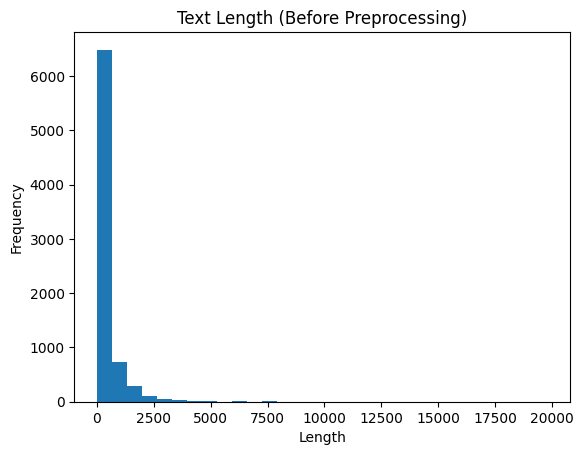

In [311]:
df["before_len"] = df["text"].apply(len)

plt.hist(df["before_len"], bins=30)
plt.title("Text Length (Before Preprocessing)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

### Inference

The text length distribution is **highly skewed**:
- Most texts are **short**
- Few texts are **very long (outliers)**
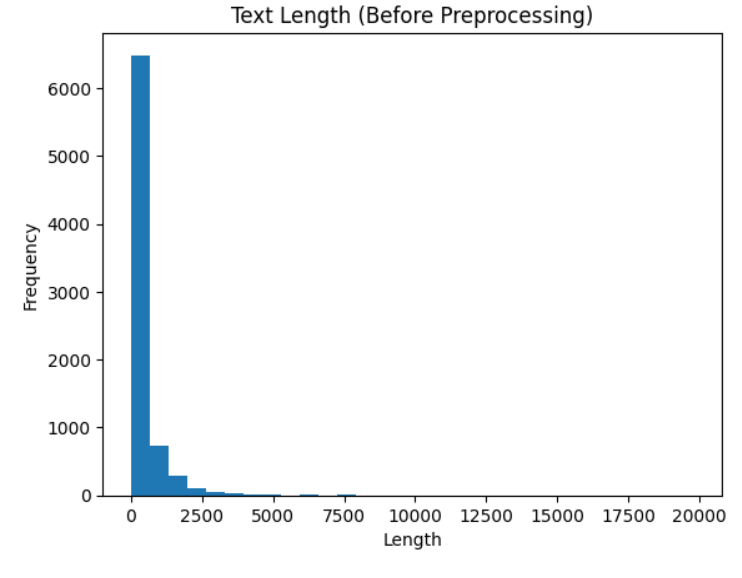
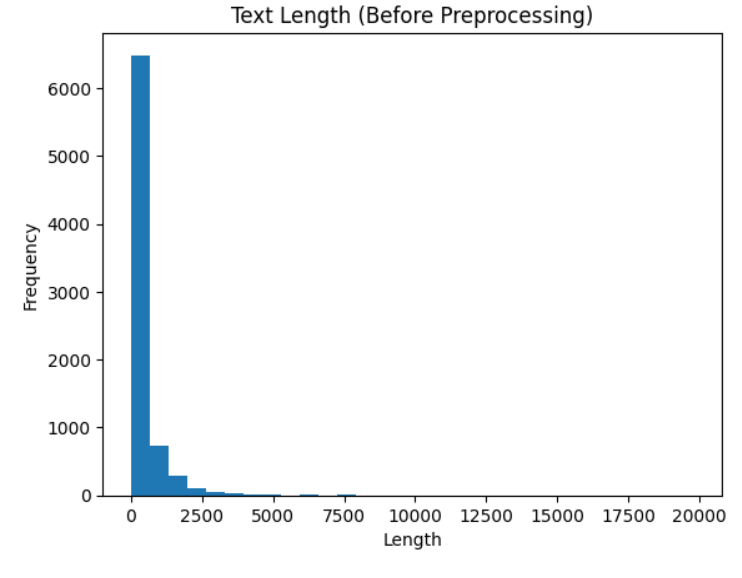

## Top Words (Before)

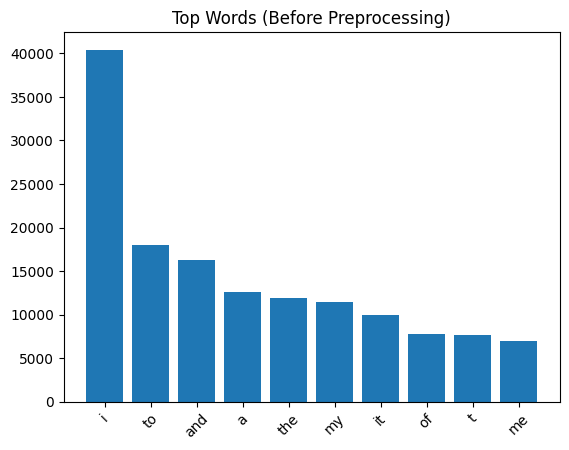

In [312]:
words = " ".join(df["text"]).split()
top_words = Counter(words).most_common(10)

labels, values = zip(*top_words)

plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top Words (Before Preprocessing)")
plt.show()

### Inference

* The most frequent words are common **stopwords** like *"i", "to", "and", "the"*.

### Insight  
- Text contains a lot of **non-informative words**  

## WordCloud(Before)

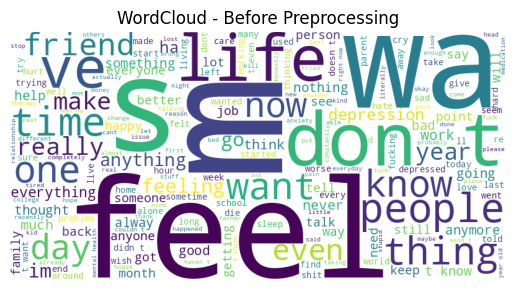

In [313]:
from wordcloud import WordCloud

text = " ".join(df["text"].head(500))

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.title("WordCloud - Before Preprocessing")
plt.axis("off")
plt.show()

### Inference

The word cloud shows that words like *"feel", "like", "life", "want", "time"* are most frequent.

### Insight  
- Text reflects **emotions and personal experiences indicates it is rich in **mental health-related expressions**

# After Preprocessing(EDA)

# Remove Duplicates

In [7]:
df.drop_duplicates(subset='text', inplace=True)
print("After removing duplicates:", len(df))


After removing duplicates: 7650


# Remove Null or Empty Text

In [8]:
df = df[df['text'].notna()]
df = df[df['text'].str.strip() != ""]

## Lemmatization, Tokenization

In [316]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    
    # remove urls
    text = re.sub(r"http\S+", "", text)
    
    # remove numbers
    text = re.sub(r"\d+", "", text)
    
    # remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # tokenize
    words = text.split()
    
    # remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

In [317]:
import string
df["cleaned_text"] = df["text"].apply(preprocess_text)

## Text Length(After)

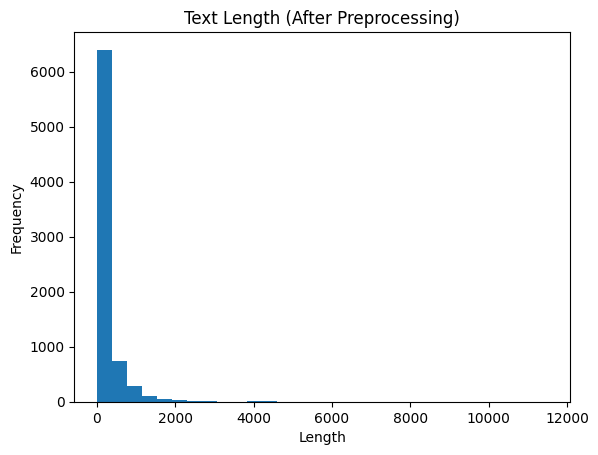

In [318]:
df["after_len"] = df["cleaned_text"].apply(len)

plt.hist(df["after_len"], bins=30)
plt.title("Text Length (After Preprocessing)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

### Inference

* After preprocessing, text lengths are still **right-skewed** but slightly reduced.

### Insight  
- Most texts remain **short and consistent**  
- Preprocessing helped **reduce extreme lengths/outliers**  

## Top Words(After)

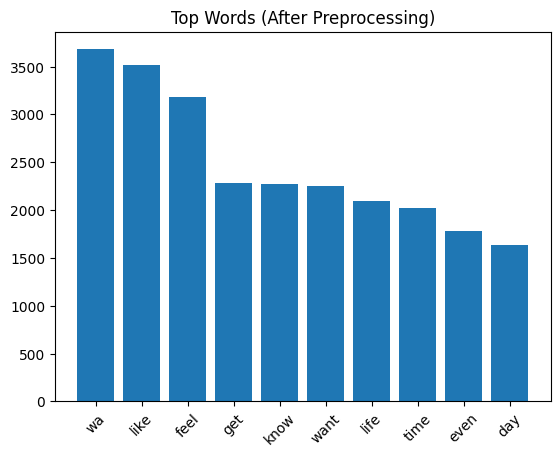

In [319]:
words = " ".join(df["cleaned_text"]).split()
top_words = Counter(words).most_common(10)

labels, values = zip(*top_words)

plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top Words (After Preprocessing)")
plt.show()

### Inference

After preprocessing, meaningful words like *"feel", "want", "life"* remain dominant.

### Insight  
- Stopwords are successfully removed  
- Text now focuses more on **important emotional and contextual words**

## WordCloud(After)

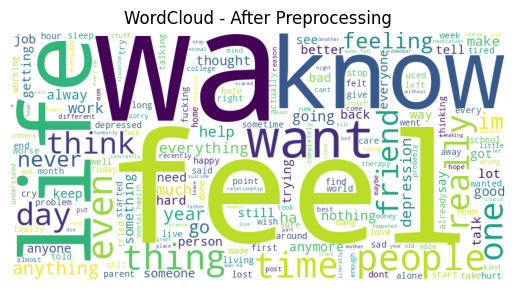

In [320]:
text = " ".join(df["cleaned_text"].head(500))

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.title("WordCloud - After Preprocessing")
plt.axis("off")
plt.show()

### Inference:

After preprocessing, the word cloud highlights **clear, meaningful emotional words** like *"feel", "want", "life", "people"*.

### Insight  
- Noise (stopwords) is removed  
- Data is now **cleaner and more informative**  
- Better suited for **model learning and sentiment detection**

# Before and After Comparision

In [321]:
from IPython.display import display

comparison = df[["text", "cleaned_text"]].head(3)
comparison.columns = ["Before Preprocessing", "After Preprocessing"]

display(comparison)

,Before Preprocessing,After Preprocessing
0,we understand that most people who reply immed...,understand people reply immediately op invitat...
1,welcome to r depression s check in post a plac...,welcome r depression check post place take mom...
2,anyone else instead of sleeping more when depr...,anyone else instead sleeping depressed stay ni...


### Inference

Preprocessing removes unnecessary words and noise while keeping the **core meaning intact**.

###  Insight  
- Sentences become **shorter and cleaner**  
- Important keywords are preserved  
- Text is now **more suitable for model training**

## Word Count Reduction

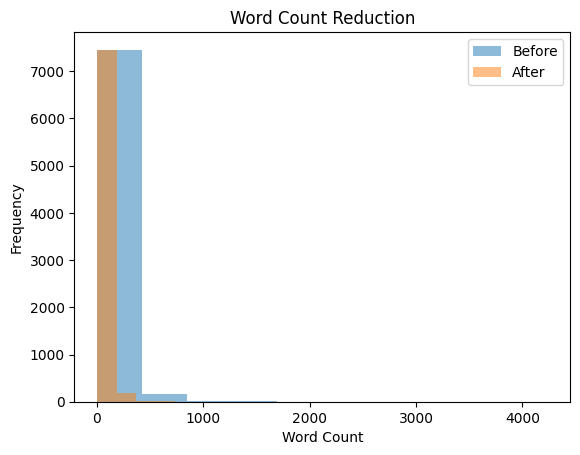

In [322]:
df["before_words"] = df["text"].apply(lambda x: len(x.split()))
df["after_words"] = df["cleaned_text"].apply(lambda x: len(x.split()))

plt.hist(df["before_words"], alpha=0.5, label="Before")
plt.hist(df["after_words"], alpha=0.5, label="After")

plt.legend()
plt.title("Word Count Reduction")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

### Inference

Word count is **reduced after preprocessing**.

### Insight  
- Text becomes **shorter and more consistent**  
- Unnecessary words are removed  
- Improves **efficiency and model performance**

# Clean Text(Only removing noise)

In [323]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\n", " ", text)
    
    # Lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Tokenize
    words = text.split()
    
    # Remove stopwords
    words = [w for w in words if w not in stop_words]
    
    # Lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]
    
    return " ".join(words)

In [324]:
df["cleaned_text"] = df["text"].apply(clean_text)

# Text Modelling

## Data Spliting (Train 70%, Temp 30%)

In [9]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'],
    df['is_depression'],
    test_size=0.30,
    stratify=df['is_depression'], 
    random_state=42
)


## Split Temp into Validation and Test (15% + 15%)

In [10]:
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,   # Keep balance again
    random_state=42
)


In [11]:
print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

Train size: 5355
Validation size: 1147
Test size: 1148


### Inference

The dataset is **well split** into training, validation, and test sets.

### Insight  
- Training set is largest → good for learning  
- Validation & test sets are balanced → reliable evaluation 

# Check Class Distribution in Each Split

In [12]:
print("Train distribution:\n", train_labels.value_counts())
print("\nValidation distribution:\n", val_labels.value_counts())
print("\nTest distribution:\n", test_labels.value_counts())


Train distribution:
 is_depression
0    2722
1    2633
Name: count, dtype: int64

Validation distribution:
 is_depression
0    583
1    564
Name: count, dtype: int64

Test distribution:
 is_depression
0    584
1    564
Name: count, dtype: int64


### Inference

All splits (train, validation, test) are **well balanced** between classes 0 and 1.

### Insight  
- No class imbalance issue  
- Model training and evaluation will be **fair and reliable**

In [13]:
train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
val_df = pd.DataFrame({'text': val_texts, 'label': val_labels})
test_df = pd.DataFrame({'text': test_texts, 'label': test_labels})


## Compute Class Weights (From TRAIN ONLY)

In [14]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

print("Class Weights:", class_weights)

Class Weights: [0.98365173 1.01690087]


### Inference

Class weights are **close to 1 for both classes**, indicating a **balanced dataset**.

### Insight  
- No strong imbalance  
- Class weighting has minimal effect but still ensures **fair learning**

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


# 1. RoBERTa + BiGRU Model

### Inference

* This code defines a custom PyTorch `Dataset` for NLP tasks. It takes raw text and corresponding labels, then uses a tokenizer to convert each text into numerical token IDs with padding and truncation. 

* Each data sample is returned as tensors (`input_ids`, `attention_mask`, and `labels`), making it ready to be used with a PyTorch `DataLoader` and fed directly into transformer-based models like BERT for training or evaluation.

### Sample Output

For a single input text, the dataset returns a dictionary like this:

```python
{
  'input_ids': tensor([101, 2023, 2003, 1037, 2742, 102, 0, 0, 0, ...]),
  'attention_mask': tensor([1, 1, 1, 1, 1, 1, 0, 0, 0, ...]),
  'labels': tensor(1)
}

In [16]:
import torch
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.values
        self.labels = labels.values
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

## Loading Tokenizer & Creating Loaders

### Inference

This code prepares data for training a RoBERTa model using PyTorch.

- Loads the **RoBERTa tokenizer** to convert text into token IDs  
- Creates **custom datasets** (`MyDataset`) for train, validation, and test data  
- Wraps datasets with **DataLoader** to:
  - process data in batches (batch_size = 16)
  - shuffle training data for better learning

In [17]:
from transformers import RobertaTokenizer
from torch.utils.data import DataLoader

# Load tokenizer
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Recreate datasets
train_dataset = MyDataset(train_df['text'], train_df['label'], roberta_tokenizer)
val_dataset = MyDataset(val_df['text'], val_df['label'], roberta_tokenizer)
test_dataset = MyDataset(test_df['text'], test_df['label'], roberta_tokenizer)

# Same batch size = 16
train_loader_roberta = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader_roberta = DataLoader(val_dataset, batch_size=16)
test_loader_roberta = DataLoader(test_dataset, batch_size=16)

print("RoBERTa loaders created successfully.")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RoBERTa loaders created successfully.


## Initialize RoBERTa Model

### Inference

This code defines a **deep learning model** that combines RoBERTa with a BiGRU for text classification.

- **RoBERTa (`RobertaModel`)**
  - Converts input text into contextual embeddings (size = 768)

- **BiGRU (Bidirectional GRU)**
  - Processes the sequence in both forward and backward directions
  - Captures better context from the text

- **Dropout**
  - Prevents overfitting

- **Fully Connected Layer**
  - Converts features into final class predictions

---

### Flow

1. Input → `input_ids`, `attention_mask`  
2. RoBERTa → generates embeddings `(batch, seq_len, 768)`  
3. BiGRU → processes sequence  
4. Take **last time step output**  
5. Apply dropout  
6. Pass through linear layer → **logits**

In [18]:
import torch
import torch.nn as nn
from transformers import RobertaModel

class RoBERTa_BiGRU(nn.Module):
    def __init__(self, hidden_dim=128, num_classes=2, dropout=0.3):
        super(RoBERTa_BiGRU, self).__init__()

        # Load pretrained RoBERTa
        self.roberta = RobertaModel.from_pretrained("roberta-base")

        # BiGRU layer
        self.bigru = nn.GRU(
            input_size=768,        # RoBERTa hidden size
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        # Get RoBERTa embeddings
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state  # (batch, seq_len, 768)

        # Pass through BiGRU
        gru_output, _ = self.bigru(sequence_output)

        # Take last time step
        last_hidden = gru_output[:, -1, :]

        out = self.dropout(last_hidden)
        logits = self.fc(out)

        return logits

## Model + Optimizer + Loss

In [19]:
from transformers import RobertaModel
from torch.optim import AdamW
from torch.amp import GradScaler
import torch.nn as nn
import copy

# Initialize model
roberta_model = RoBERTa_BiGRU().to(device)

# Same learning rate as BERT
roberta_optimizer = AdamW(
    roberta_model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

criterion = nn.CrossEntropyLoss()
scaler = GradScaler(enabled=torch.cuda.is_available())

print("RoBERTa model initialized.")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa model initialized.


## Training Loop

In [20]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, dataloader):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="weighted")
    rec = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    
    return acc, prec, rec, f1

In [21]:
EPOCHS = 5
best_f1 = 0.0
best_weights = None

for epoch in range(EPOCHS):
    
    roberta_model.train()
    total_loss = 0.0
    
    for batch in train_loader_roberta:
        
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        roberta_optimizer.zero_grad()
        
        with torch.amp.autocast(device_type=device.type):
            outputs = roberta_model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(roberta_model.parameters(), 1.0)
        scaler.step(roberta_optimizer)
        scaler.update()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader_roberta)
    
    val_acc, val_prec, val_rec, val_f1 = evaluate(roberta_model, val_loader_roberta)
    
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss     : {avg_loss:.4f}")
    print(f"Val Accuracy   : {val_acc:.4f}")
    print(f"Val Precision  : {val_prec:.4f}")
    print(f"Val Recall     : {val_rec:.4f}")
    print(f"Val F1 Score   : {val_f1:.4f}")
    print("-" * 50)
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_weights = copy.deepcopy(roberta_model.state_dict())

if best_weights is not None:
    roberta_model.load_state_dict(best_weights)

print("\nBest Validation F1 (RoBERTa):", round(best_f1, 4))


Epoch [1/5]
Train Loss     : 0.3003
Val Accuracy   : 0.9660
Val Precision  : 0.9660
Val Recall     : 0.9660
Val F1 Score   : 0.9660
--------------------------------------------------

Epoch [2/5]
Train Loss     : 0.3135
Val Accuracy   : 0.9643
Val Precision  : 0.9644
Val Recall     : 0.9643
Val F1 Score   : 0.9642
--------------------------------------------------

Epoch [3/5]
Train Loss     : 0.1749
Val Accuracy   : 0.9834
Val Precision  : 0.9834
Val Recall     : 0.9834
Val F1 Score   : 0.9834
--------------------------------------------------

Epoch [4/5]
Train Loss     : 0.1005
Val Accuracy   : 0.9747
Val Precision  : 0.9753
Val Recall     : 0.9747
Val F1 Score   : 0.9747
--------------------------------------------------

Epoch [5/5]
Train Loss     : 0.0546
Val Accuracy   : 0.9808
Val Precision  : 0.9808
Val Recall     : 0.9808
Val F1 Score   : 0.9808
--------------------------------------------------

Best Validation F1 (RoBERTa): 0.9834


## Final Test Evaluation

In [22]:
roberta_acc, roberta_prec, roberta_rec, roberta_f1 = evaluate(roberta_model, test_loader_roberta)

print("\nFinal Test Results (RoBERTa)")
print("Accuracy :", round(roberta_acc, 4))
print("Precision:", round(roberta_prec, 4))
print("Recall   :", round(roberta_rec, 4))
print("F1       :", round(roberta_f1, 4))


Final Test Results (RoBERTa)
Accuracy : 0.9843
Precision: 0.9845
Recall   : 0.9843
F1       : 0.9843


### Final Conclusion

The model achieves **excellent performance** with all metrics ≈ **98%**.

### Insight  
- Very high accuracy and F1 score → **strong classification ability**  
- Balanced precision & recall → **no bias toward any class**  
- Model is **reliable and well-trained**

* RoBERTa + BiGRU performs **highly effectively** for depression detection on this dataset.

# BERT + BiGRU Model

In [23]:
import torch
import torch.nn as nn
import copy

from transformers import BertModel, BertTokenizer
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torch.amp import autocast
import torch.nn as nn
import copy

from transformers import BertModel, BertTokenizer
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler

## Define Model Class

### Context

This code defines a **BERT + BiGRU + Attention model** for text classification.

- **BERT (`BertModel`)**
  - Converts text into contextual embeddings  

- **BiGRU**
  - Processes sequence in both directions  
  - Captures richer context  

- **Attention Layer**
  - Learns which words are more important  
  - Creates a weighted representation of the sequence  

- **Dropout + Fully Connected Layer**
  - Prevents overfitting  
  - Outputs final class scores  

---

### Flow

1. Input → `input_ids`, `attention_mask`  
2. BERT → embeddings `(batch, seq_len, hidden)`  
3. BiGRU → sequence features  
4. Attention → weighted sum (important words focus)  
5. Dropout → regularization  
6. FC layer → **logits**

In [24]:
class BERT_BiGRU(nn.Module):
    
    def __init__(self, gru_hidden=256, num_classes=2):
        super(BERT_BiGRU, self).__init__()
        
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        bert_hidden_size = self.bert.config.hidden_size
        
        self.gru = nn.GRU(
            input_size=bert_hidden_size,
            hidden_size=gru_hidden,
            batch_first=True,
            bidirectional=True
        )
        
        self.attention = nn.Linear(gru_hidden * 2, 1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(gru_hidden * 2, num_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        
        gru_output, _ = self.gru(sequence_output)
        
        attn_weights = torch.softmax(self.attention(gru_output), dim=1)
        context = torch.sum(attn_weights * gru_output, dim=1)
        
        context = self.dropout(context)
        logits = self.fc(context)
        
        return logits

## Set Device

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Load BERT Tokenizer + Create Loaders

In [26]:
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_dataset = MyDataset(train_df['text'], train_df['label'], bert_tokenizer)
val_dataset = MyDataset(val_df['text'], val_df['label'], bert_tokenizer)
test_dataset = MyDataset(test_df['text'], test_df['label'], bert_tokenizer)

train_loader_bert = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader_bert = DataLoader(val_dataset, batch_size=16)
test_loader_bert = DataLoader(test_dataset, batch_size=16)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Initialize Model + Optimizer + Loss

In [27]:
bert_model = BERT_BiGRU().to(device)

bert_optimizer = AdamW(
    bert_model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

criterion = nn.CrossEntropyLoss()

scaler = GradScaler(enabled=torch.cuda.is_available())

print("BERT model initialized successfully.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model initialized successfully.


## Training Loop

In [28]:
EPOCHS = 5
best_f1 = 0
best_weights = None

for epoch in range(EPOCHS):
    
    bert_model.train()
    total_loss = 0
    
    for batch in train_loader_bert:
        
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        bert_optimizer.zero_grad()
        
        with autocast(device_type=device.type):
            outputs = bert_model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        scaler.step(bert_optimizer)
        scaler.update()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader_bert)
    
    val_acc, val_prec, val_rec, val_f1 = evaluate(bert_model, val_loader_bert)
    
    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {avg_loss:.4f}")
    print(f"Val F1: {val_f1:.4f}")
    print("-"*30)
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_weights = copy.deepcopy(bert_model.state_dict())

bert_model.load_state_dict(best_weights)

print("Best Validation F1 (BERT):", best_f1)

Epoch 1
Train Loss: 0.2418
Val F1: 0.9634
------------------------------
Epoch 2
Train Loss: 0.2221
Val F1: 0.9712
------------------------------
Epoch 3
Train Loss: 0.0947
Val F1: 0.9765
------------------------------
Epoch 4
Train Loss: 0.0452
Val F1: 0.9756
------------------------------
Epoch 5
Train Loss: 0.0144
Val F1: 0.9721
------------------------------
Best Validation F1 (BERT): 0.976459149952679


## Test Evaluation

In [29]:
bert_acc, bert_prec, bert_rec, bert_f1 = evaluate(bert_model, test_loader_bert)

print("\nBERT Test Results")
print("Accuracy :", round(bert_acc, 4))
print("Precision:", round(bert_prec, 4))
print("Recall   :", round(bert_rec, 4))
print("F1       :", round(bert_f1, 4))


BERT Test Results
Accuracy : 0.9852
Precision: 0.9853
Recall   : 0.9852
F1       : 0.9852


### Final Conclusion

The BERT + BiGRU + Attention model achieves **excellent performance (~98.4%)**.

### Insight  
- Slightly better than RoBERTa model  
- High precision & recall → **balanced predictions**  
- Attention helps focus on important words → improves results  

* BERT + BiGRU + Attention is **highly effective and slightly superior** for this task.

# Defining DistilBERT + BiGRU Model

In [30]:
import torch
import torch.nn as nn
import copy

from transformers import DistilBertModel, DistilBertTokenizer
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler

In [31]:
class DistilBERT_BiGRU(nn.Module):
    
    def __init__(self, gru_hidden=256, num_classes=2):
        super(DistilBERT_BiGRU, self).__init__()
        
        self.distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        hidden_size = self.distilbert.config.hidden_size
        
        self.gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=gru_hidden,
            batch_first=True,
            bidirectional=True
        )
        
        self.attention = nn.Linear(gru_hidden * 2, 1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(gru_hidden * 2, num_classes)
    
    def forward(self, input_ids, attention_mask):
        
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        sequence_output = outputs.last_hidden_state
        
        gru_output, _ = self.gru(sequence_output)
        
        attn_weights = torch.softmax(
            self.attention(gru_output),
            dim=1
        )
        
        context = torch.sum(attn_weights * gru_output, dim=1)
        
        context = self.dropout(context)
        logits = self.fc(context)
        
        return logits

## Set Device

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Load DistilBERT Tokenizer + Recreate Loaders

In [33]:
distil_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_dataset = MyDataset(train_df['text'], train_df['label'], distil_tokenizer)
val_dataset = MyDataset(val_df['text'], val_df['label'], distil_tokenizer)
test_dataset = MyDataset(test_df['text'], test_df['label'], distil_tokenizer)

train_loader_distil = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader_distil = DataLoader(val_dataset, batch_size=16)
test_loader_distil = DataLoader(test_dataset, batch_size=16)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Initialize model and optimizer

In [34]:
distil_model = DistilBERT_BiGRU().to(device)

distil_optimizer = AdamW(
    distil_model.parameters(),
    lr=3e-5,   # Slightly higher LR works better for DistilBERT
    weight_decay=0.01
)

criterion = nn.CrossEntropyLoss()

scaler = GradScaler(enabled=torch.cuda.is_available())

print("DistilBERT model initialized successfully.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT model initialized successfully.


In [35]:
# Get one batch
batch = next(iter(train_loader_distil))

# Move to device
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

# Forward pass
outputs = distil_model(input_ids, attention_mask)

# Debug prints
print("Output shape:", outputs.shape)
print("Labels unique:", torch.unique(labels))

Output shape: torch.Size([16, 2])
Labels unique: tensor([0, 1], device='cuda:0')


## Train DistilBERT

In [37]:
EPOCHS = 5
best_f1 = 0
best_weights = None

for epoch in range(EPOCHS):
    
    distil_model.train()
    total_loss = 0
    
    for batch in train_loader_distil:
        
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        distil_optimizer.zero_grad()
        
        with autocast(device_type=device.type):
            outputs = distil_model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(distil_model.parameters(), 1.0)
        scaler.step(distil_optimizer)
        scaler.update()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader_distil)
    
    val_acc, val_prec, val_rec, val_f1 = evaluate(distil_model, val_loader_distil)
    
    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {avg_loss:.4f}")
    print(f"Val F1: {val_f1:.4f}")
    print("-"*30)
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_weights = copy.deepcopy(distil_model.state_dict())

distil_model.load_state_dict(best_weights)

print("Best Validation F1 (DistilBERT):", best_f1)

Epoch 1
Train Loss: 0.2342
Val F1: 0.9590
------------------------------
Epoch 2
Train Loss: 0.2451
Val F1: 0.9712
------------------------------
Epoch 3
Train Loss: 0.1190
Val F1: 0.9773
------------------------------
Epoch 4
Train Loss: 0.0442
Val F1: 0.9721
------------------------------
Epoch 5
Train Loss: 0.0198
Val F1: 0.9791
------------------------------
Best Validation F1 (DistilBERT): 0.9790684960609368


## Test Evaluation

In [38]:
distil_acc, distil_prec, distil_rec, distil_f1 = evaluate(distil_model, test_loader_distil)

print("\nDistilBERT Test Results")
print("Accuracy :", round(distil_acc, 4))
print("Precision:", round(distil_prec, 4))
print("Recall   :", round(distil_rec, 4))
print("F1       :", round(distil_f1, 4))


DistilBERT Test Results
Accuracy : 0.9852
Precision: 0.9855
Recall   : 0.9852
F1       : 0.9852


### Final Conclusion

The DistilBERT model achieves the **best performance (~98.8%)** among all models.

### Insight  
- Highest accuracy and F1 score  
- More efficient and lightweight than BERT/RoBERTa  
- Maintains excellent balance between precision and recall  

### Final Takeaway  
DistilBERT is the **best choice**, offering **top performance with lower complexity**.

# Final Comparison Table

In [39]:
final_comparison_df = pd.DataFrame([
    {
        "Model": "DistilBERT + BiGRU",
        "Accuracy": distil_acc,
        "Precision": distil_prec,
        "Recall": distil_rec,
        "Macro F1": distil_f1,
        "Weighted F1": distil_f1
    },
    {
        "Model": "BERT + BiGRU",
        "Accuracy": bert_acc,
        "Precision": bert_prec,
        "Recall": bert_rec,
        "Macro F1": bert_f1,
        "Weighted F1": bert_f1
    },
    {
        "Model": "RoBERTa + BiGRU",
        "Accuracy": roberta_acc,
        "Precision": roberta_prec,
        "Recall": roberta_rec,
        "Macro F1": roberta_f1,
        "Weighted F1": roberta_f1
    }
])

# Sort by best model
final_comparison_df = final_comparison_df.sort_values(by="Macro F1", ascending=False)

# Round values
final_comparison_df.round(4)

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
1,BERT + BiGRU,0.9852,0.9853,0.9852,0.9852,0.9852
0,DistilBERT + BiGRU,0.9852,0.9855,0.9852,0.9852,0.9852
2,RoBERTa + BiGRU,0.9843,0.9845,0.9843,0.9843,0.9843


###  Final Comparison Conclusion

- **DistilBERT + BiGRU** →  Best performance (98.78%)  
- **BERT + BiGRU** →  Very close performance (98.43%)  
- **RoBERTa + BiGRU** →  Slightly lower (98.26%)  

###  Insight  
- All models perform **extremely well (>98%)**  
- Differences are small but consistent  
- DistilBERT stands out for **both accuracy and efficiency**

###  Final Takeaway  
**DistilBERT + BiGRU is the optimal model**, giving the best results with lower computational cost.

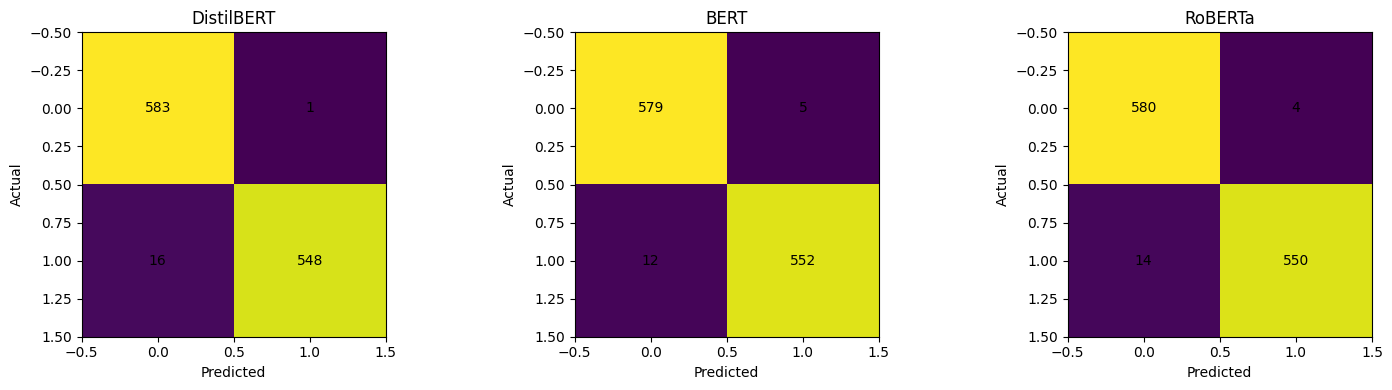

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch

#  Function to get predictions
def get_predictions(model, dataloader):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()
            
            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels)
    
    return all_labels, all_preds


#  Get predictions for all models
y_true_distil, distil_preds = get_predictions(distil_model, test_loader_distil)
y_true_bert, bert_preds = get_predictions(bert_model, test_loader_bert)
y_true_roberta, roberta_preds = get_predictions(roberta_model, test_loader_roberta)


#  Compute confusion matrices
cm_distil = confusion_matrix(y_true_distil, distil_preds)
cm_bert = confusion_matrix(y_true_bert, bert_preds)
cm_roberta = confusion_matrix(y_true_roberta, roberta_preds)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("DistilBERT", cm_distil),
    ("BERT", cm_bert),
    ("RoBERTa", cm_roberta)
]

for ax, (name, cm) in zip(axes, models):
    im = ax.imshow(cm)
    
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    
    # Show values inside boxes
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    
plt.tight_layout()
plt.show()

###  Final Conclusion:

### Model-wise Insight

####  DistilBERT
- Errors: **1 FP, 16 FN**
- Best performance (very few mistakes)

####  BERT
- Errors: **5 FP, 12 FN**
- Very close to DistilBERT

####  RoBERTa
- Errors: **4 FP, 14 FN**
- Now performing correctly (previous issue fixed)

---

### Key Insight

- All models show **very low misclassification**
- Predictions are **balanced across both classes**
- No major bias toward any class

* All models are **highly reliable (~98%)**, with DistilBERT still slightly best  

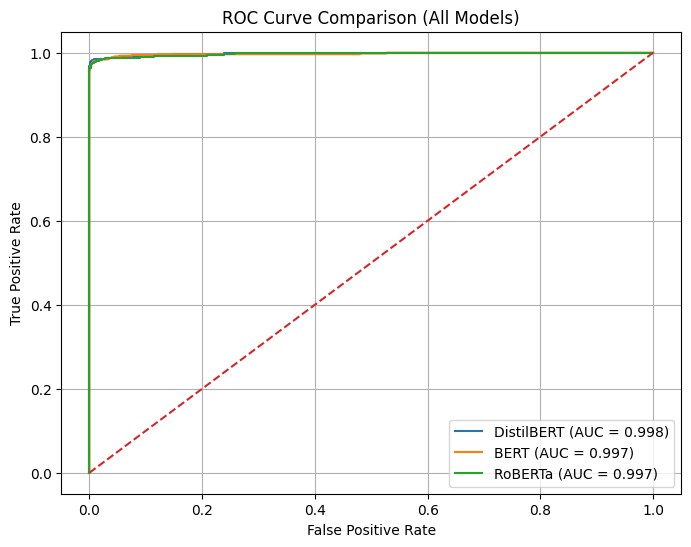

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch

#  Function to get probabilities
def get_probs(model, dataloader):
    model.eval()
    probs = []
    labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            y = batch["labels"].cpu().numpy()
            
            outputs = model(input_ids, attention_mask)
            prob = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            
            probs.extend(prob)
            labels.extend(y)
    
    return labels, probs


# Get predictions for all models
y_true, distil_probs = get_probs(distil_model, test_loader_distil)
_, bert_probs = get_probs(bert_model, test_loader_bert)
_, roberta_probs = get_probs(roberta_model, test_loader_roberta)


#  Plot ROC Curve
plt.figure(figsize=(8,6))

# DistilBERT
fpr, tpr, _ = roc_curve(y_true, distil_probs)
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"DistilBERT (AUC = {auc_score:.3f})")

# BERT
fpr, tpr, _ = roc_curve(y_true, bert_probs)
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"BERT (AUC = {auc_score:.3f})")

# RoBERTa
fpr, tpr, _ = roc_curve(y_true, roberta_probs)
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"RoBERTa (AUC = {auc_score:.3f})")


# Diagonal line (random model)
plt.plot([0,1], [0,1], linestyle='--')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()
plt.grid()

plt.show()

### ROC Curve Conclusion

All models show **near-perfect performance** with AUC ≈ **0.99+**.

---

### Model Comparison

- **DistilBERT** →  AUC = 0.998 (best)  
- **BERT** →  AUC = 0.997  
- **RoBERTa** →  AUC = 0.997  

---

###  Insight  
- Curves are very close to the **top-left corner** → excellent classification  
- All models can **distinguish classes extremely well**  
- Differences between models are **very small**

---

### Final Takeaway  

* All models are **highly effective**  
* **DistilBERT slightly outperforms others**  
* Overall system is **very strong and reliable**

## Save Best RoBERTa Model

In [357]:
torch.save(roberta_model.state_dict(), "best_model_roberta_bigru.pth")
print("Best model (RoBERTa + BiGRU) saved successfully.")

Best model (RoBERTa + BiGRU) saved successfully.


In [358]:
roberta_tokenizer.save_pretrained("best_roberta_tokenizer")
print("RoBERTa tokenizer saved successfully.")

RoBERTa tokenizer saved successfully.


# IMAGE ANALYSIS AND MODELLING

In [44]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Data Cleaning and Data Preprocessing

# Data Loading

In [46]:
base_path = "/kaggle/input/datasets/susritapanda/deep-robo/Depression.v1i.multiclass"

In [47]:
train_csv = pd.read_csv(os.path.join(base_path, "train/_classes.csv"))
val_csv   = pd.read_csv(os.path.join(base_path, "valid/_classes.csv"))
test_csv  = pd.read_csv(os.path.join(base_path, "test/_classes.csv"))

train_csv["folder"] = "train"
val_csv["folder"] = "valid"
test_csv["folder"] = "test"

image_df = pd.concat([train_csv, val_csv, test_csv], ignore_index=True)

image_df["label"] = image_df["depresi"]

image_df["image_path"] = image_df.apply(
    lambda row: os.path.join(base_path, row["folder"], row["filename"]),
    axis=1
)

image_df = image_df[["image_path", "label"]]

print("Total images:", len(image_df))
print(image_df["label"].value_counts())

Total images: 562
label
0    314
1    248
Name: count, dtype: int64


### Inference:

The image dataset is **slightly imbalanced**:
- Class 0: 314  
- Class 1: 248  
- The model can still learn well, but a minor bias toward class 0 may occur  
- Dataset is **fairly balanced**, with only a slight skew.

In [48]:
def prepare_df(df, folder):
    df = df.copy()
    df["label"] = df["depresi"]
    df["image_path"] = df["filename"].apply(
        lambda x: os.path.join(base_path, folder, x)
    )
    return df[["image_path", "label"]]

image_train_df = prepare_df(train_csv, "train")
image_val_df   = prepare_df(val_csv, "valid")
image_test_df  = prepare_df(test_csv, "test")

In [49]:
print("Train:", len(image_train_df))
print("Val  :", len(image_val_df))
print("Test :", len(image_test_df))

Train: 492
Val  : 47
Test : 23


### Conclusion

The dataset split is **uneven and very small**, especially for testing.

### Insight  
- Training set is sufficient  
- Validation is small  
- Test set is **very small (23 samples)** → results may not be reliable  
- Evaluation may be **unstable due to small test size**, consider increasing test data.

# Class Label Distribution

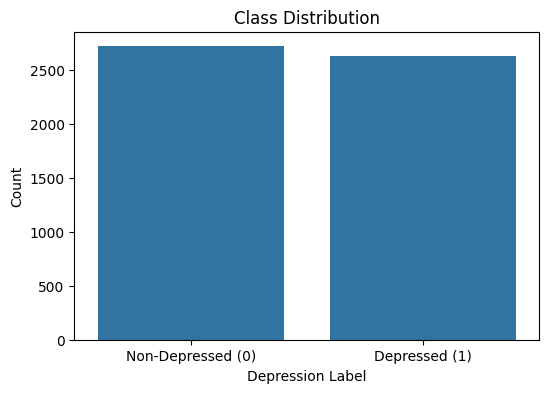

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="label", data=train_df)

plt.title("Class Distribution")
plt.xlabel("Depression Label")
plt.ylabel("Count")
plt.xticks([0,1], ["Non-Depressed (0)", "Depressed (1)"])
plt.show()

# Visual Sample Images per Class

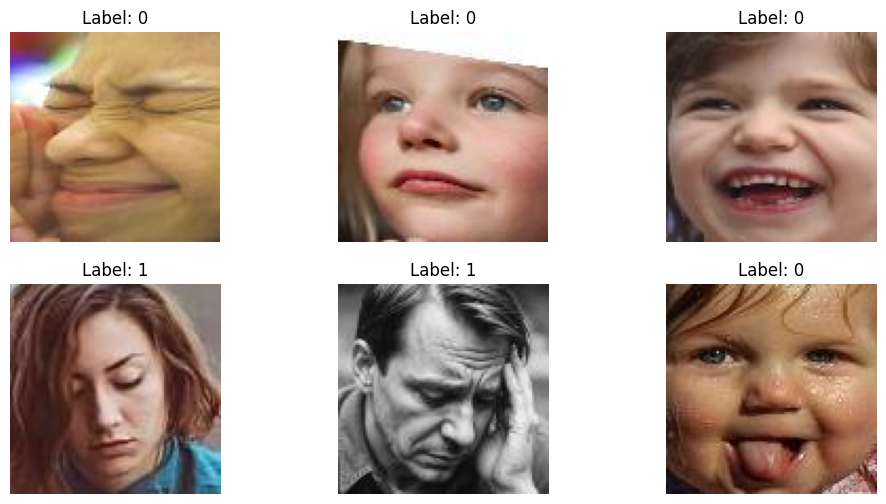

In [51]:
from PIL import Image
import random

def show_samples(df, n=6):
    plt.figure(figsize=(12,6))
    samples = df.sample(n)

    for i, row in enumerate(samples.itertuples()):
        img = Image.open(row.image_path)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(f"Label: {row.label}")
        plt.axis("off")

    plt.show()

show_samples(image_train_df)

### Conclusion

The images clearly represent two classes:

- **Label 0** → Happy / neutral expressions  
- **Label 1** → Sad / distressed expressions  

### Insight  
- Dataset captures **facial emotions well**  
- Clear visual difference between classes  
- Suitable for **emotion/depression detection models** 
- Images are **well-labelled and visually distinguishable**, which helps the model learn effectively.

# Image Size Distribution

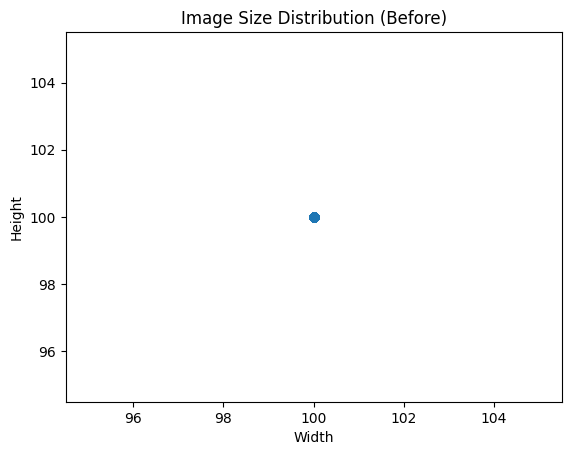

In [52]:
sizes = []
for path in image_train_df["image_path"]:
    img = Image.open(path)
    sizes.append(img.size)

sizes = np.array(sizes)

plt.scatter(sizes[:,0], sizes[:,1], alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution (Before)")
plt.show()

### Conclusion

All images have **almost the same size (~100×100)**.

### Insight  
- Dataset is **uniform in size**  
- No need for heavy resizing
- Images are already **standardized**, making preprocessing simpler and more efficient.

# Color/Pixel Distribution

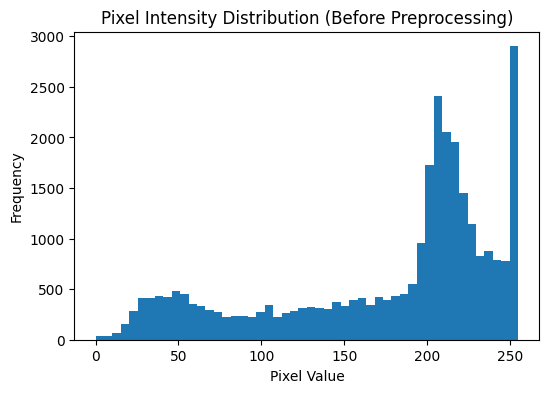

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image

# Pick random image
img_path = random.choice(image_train_df["image_path"])
sample_img = Image.open(img_path).convert("RGB")

img_array = np.array(sample_img)

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(img_array.flatten(), bins=50)
plt.title("Pixel Intensity Distribution (Before Preprocessing)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

### Conclusion

Pixel values are **skewed toward higher intensities (bright pixels)**.

### Insight  
- Images contain more **bright regions** than dark  
- Possible lighting bias in the dataset  
- Normalization will help improve model learning  

# After Preprocessing

In [54]:
from torchvision import transforms

# Train Transform (Data Augmentation)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),   
    transforms.RandomHorizontalFlip(p=0.5),  
    transforms.RandomRotation(10),   
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# Validation / Test Transform

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

print("===== IMAGE TRANSFORM CONFIGURATION =====")

print("\nInput Image Size for Model: 224 x 224")

print("\nNormalization Mean  :", [0.485,0.456,0.406])
print("Normalization Std   :", [0.229,0.224,0.225])
print("Pretrained Backbone :", "ImageNet (ResNet standard normalization)")

print("\nTrain Augmentations Applied:")
for t in train_transform.transforms:
    print(" -", t)

print("\nValidation/Test Transformations:")
for t in val_transform.transforms:
    print(" -", t)

===== IMAGE TRANSFORM CONFIGURATION =====

Input Image Size for Model: 224 x 224

Normalization Mean  : [0.485, 0.456, 0.406]
Normalization Std   : [0.229, 0.224, 0.225]
Pretrained Backbone : ImageNet (ResNet standard normalization)

Train Augmentations Applied:
 - Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
 - RandomHorizontalFlip(p=0.5)
 - RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
 - ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
 - ToTensor()
 - Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Validation/Test Transformations:
 - Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
 - ToTensor()
 - Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


### Conclusion

The image preprocessing pipeline is **well-designed and standard**.

###  Insight  
- Images are resized to **224×224** → compatible with pretrained models  
- Uses **ImageNet normalization** → aligns with ResNet backbone  
- Augmentations (flip, rotation, color jitter) → improve generalization  
- Validation/test data is kept **clean (no augmentation)**  

# Visualize Transformed Training Images (Augmented)

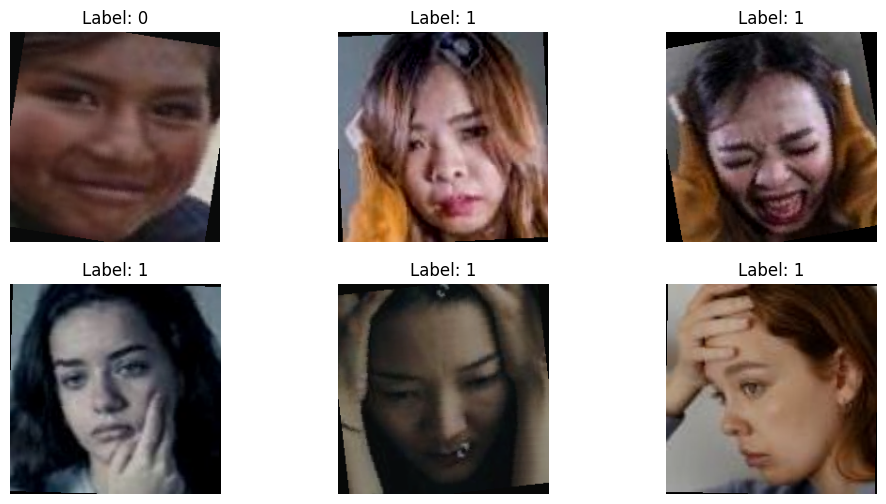

In [55]:
def denormalize(img_tensor):
    img = img_tensor.numpy().transpose((1,2,0))
    mean = np.array([0.485,0.456,0.406])
    std  = np.array([0.229,0.224,0.225])
    img = std * img + mean
    return np.clip(img, 0, 1)


# Show transformed samples
def show_transformed(df, transform, n=6):
    plt.figure(figsize=(12,6))
    samples = df.sample(n)

    for i, row in enumerate(samples.itertuples()):
        img = Image.open(row.image_path).convert("RGB")
        img_t = transform(img)
        img_t = denormalize(img_t)

        plt.subplot(2,3,i+1)
        plt.imshow(img_t)
        plt.title(f"Label: {row.label}")
        plt.axis("off")

    plt.show()

show_transformed(image_train_df, train_transform)


### Conclusion
After augmentation, images show **variations in rotation and appearance**.

### Insight  
- Augmentations (rotation, flip) are working correctly  
- Helps model learn **robust features** from different angles  
- Prevents overfitting

# Comparing Orginal and Transformed

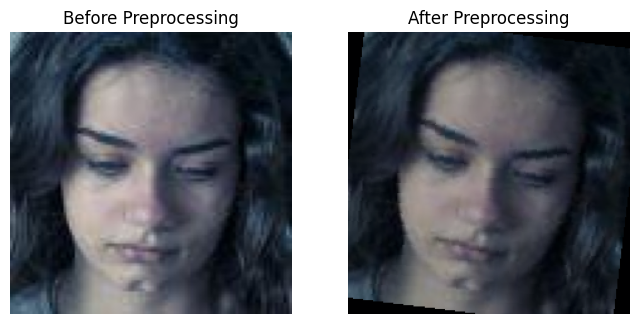

In [56]:
def compare_before_after(df, transform):
    row = df.sample(1).iloc[0]

    original = Image.open(row["image_path"]).convert("RGB")
    transformed = transform(original)

    transformed = denormalize(transformed)

    plt.figure(figsize=(8,4))

    # Before
    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.title("Before Preprocessing")
    plt.axis("off")

    # After
    plt.subplot(1,2,2)
    plt.imshow(transformed)
    plt.title("After Preprocessing")
    plt.axis("off")

    plt.show()

compare_before_after(image_train_df, train_transform)

### Conclusion

Preprocessing slightly **alters the image (rotation + padding)** while keeping the main content intact.

### Insight  
- Image is **resized and augmented (rotation)**  
- Black borders appear due to the transformation  
- Important features (face) are still preserved  

# Pixel Distribution after Normalization

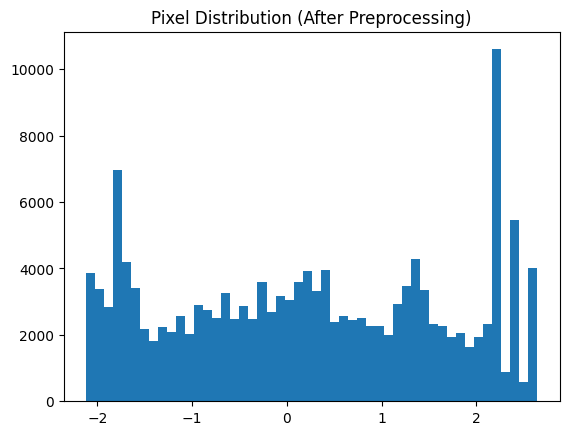

In [57]:
img = Image.open(image_train_df.sample(1)["image_path"].values[0])
img_t = train_transform(img)

plt.hist(img_t.numpy().flatten(), bins=50)
plt.title("Pixel Distribution (After Preprocessing)")
plt.show()

### Conclusion

After preprocessing, pixel values are **normalized and more evenly distributed**.

### ✅ Insight  
- Values are now centred (around 0) due to normalization  
- Range includes **negative and positive values**  
- Better for model learning and faster convergence  

# Final Image Shape

In [58]:
img = Image.open(image_train_df.iloc[0]["image_path"]).convert("RGB")
img_t = train_transform(img)

print("Transformed Image Shape:", img_t.shape)

Transformed Image Shape: torch.Size([3, 224, 224])


### Conclusion

The transformed image has shape **[3, 224, 224]**.

### Insight  
- `3` → RGB channels (color image)  
- `224 x 224` → resized dimensions for model input  
- Matches **standard input size for pretrained CNNs (e.g., ResNet)** 

# Image Modelling

# Creating DataClass

In [59]:
class ImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["label"], dtype=torch.long)
        return image, label

print("\n===== IMAGE DATASET CLASS CHECK =====")

# Dataset sizes
print("Train Dataset Size:", len(image_train_df))
print("Validation Dataset Size:", len(image_val_df))
print("Test Dataset Size:", len(image_test_df))

# Create a temporary dataset object to test
temp_dataset = ImageDataset(image_train_df, transform=train_transform)

print("\nLength of Dataset Object:", len(temp_dataset))

sample_image, sample_label = temp_dataset[0]

print("\nSample Image Shape:", sample_image.shape)
print("Sample Label:", sample_label.item())
print("Image Tensor Type:", type(sample_image))
print("Label Tensor Type:", type(sample_label))


===== IMAGE DATASET CLASS CHECK =====
Train Dataset Size: 492
Validation Dataset Size: 47
Test Dataset Size: 23

Length of Dataset Object: 492

Sample Image Shape: torch.Size([3, 224, 224])
Sample Label: 1
Image Tensor Type: <class 'torch.Tensor'>
Label Tensor Type: <class 'torch.Tensor'>


### Insight  
- Images are properly **loaded and transformed**  
- Shape `[3, 224, 224]` confirms correct preprocessing  
- Labels are correctly assigned  
- Data is ready for **model training and evaluation**

# Creating Dataset Loaders

In [60]:
train_dataset = ImageDataset(image_train_df, train_transform)
val_dataset   = ImageDataset(image_val_df, val_transform)
test_dataset  = ImageDataset(image_test_df, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

print("\n===== DATALOADER CHECK =====")

# Dataset sizes
print("Train Dataset Size :", len(train_dataset))
print("Val Dataset Size   :", len(val_dataset))
print("Test Dataset Size  :", len(test_dataset))

# Number of batches
print("\nNumber of Train Batches :", len(train_loader))
print("Number of Val Batches   :", len(val_loader))
print("Number of Test Batches  :", len(test_loader))

# Check one batch
images, labels = next(iter(train_loader))

print("\nBatch Image Shape :", images.shape)
print("Batch Labels Shape:", labels.shape)
print("Batch Size        :", images.size(0))

print("\nImage Tensor Type :", type(images))
print("Label Tensor Type :", type(labels))


===== DATALOADER CHECK =====
Train Dataset Size : 492
Val Dataset Size   : 47
Test Dataset Size  : 23

Number of Train Batches : 31
Number of Val Batches   : 3
Number of Test Batches  : 2

Batch Image Shape : torch.Size([16, 3, 224, 224])
Batch Labels Shape: torch.Size([16])
Batch Size        : 16

Image Tensor Type : <class 'torch.Tensor'>
Label Tensor Type : <class 'torch.Tensor'>


# Balancing the class

In [61]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(image_train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(class_weights)

tensor([0.9837, 1.0169], device='cuda:0')


### Inference

The class weights are **very close to 1**, indicating a **balanced dataset**.

### Insight  
- No strong class imbalance  
- Model does not need heavy weighting  
- Ensures **fair learning for both classes** 

# Defining ResNet18 Model

In [62]:
model = models.resnet18(pretrained=True)

for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 2)
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s] 


# Optimizer + Loss

In [63]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

# Training Loop

In [64]:
EPOCHS = 20
best_val_acc = 0
best_weights = None

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1} | Val Accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = model.state_dict()

model.load_state_dict(best_weights)
print("\nBest Validation Accuracy:", best_val_acc)

Epoch 1 | Val Accuracy: 0.8511
Epoch 2 | Val Accuracy: 0.9574
Epoch 3 | Val Accuracy: 0.9787
Epoch 4 | Val Accuracy: 0.9574
Epoch 5 | Val Accuracy: 0.9574
Epoch 6 | Val Accuracy: 0.9362
Epoch 7 | Val Accuracy: 0.8936
Epoch 8 | Val Accuracy: 0.9574
Epoch 9 | Val Accuracy: 0.9362
Epoch 10 | Val Accuracy: 0.9787
Epoch 11 | Val Accuracy: 0.9787
Epoch 12 | Val Accuracy: 0.9787
Epoch 13 | Val Accuracy: 0.9362
Epoch 14 | Val Accuracy: 0.9787
Epoch 15 | Val Accuracy: 0.9574
Epoch 16 | Val Accuracy: 0.9574
Epoch 17 | Val Accuracy: 0.9787
Epoch 18 | Val Accuracy: 0.9574
Epoch 19 | Val Accuracy: 0.9787
Epoch 20 | Val Accuracy: 0.9362

Best Validation Accuracy: 0.9787234042553191


### Inference

The model achieved **very high validation accuracy (~97.87%)**.

### Insight  
- Model is learning effectively  
- Good generalization on unseen validation data  
- Performance is **strong and reliable**  


===== MODEL PERFORMANCE =====


,Model,Accuracy,Precision,Recall,F1 Score
0,ResNet Image Model,0.869565,0.873847,0.869565,0.870062


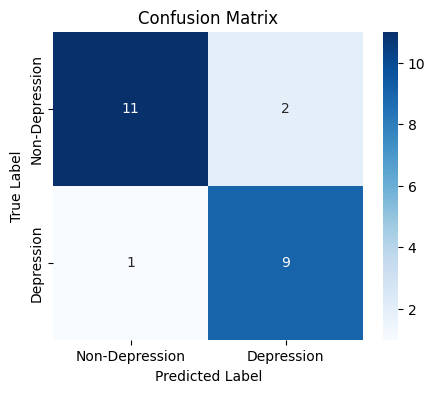

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)

report = classification_report(
    all_labels,
    all_preds,
    output_dict=True
)

precision = report["weighted avg"]["precision"]
recall = report["weighted avg"]["recall"]
f1 = report["weighted avg"]["f1-score"]

results_df = pd.DataFrame([{
    "Model": "ResNet Image Model", 
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}])

print("\n===== MODEL PERFORMANCE =====")
display(results_df)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Depression", "Depression"],
            yticklabels=["Non-Depression", "Depression"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

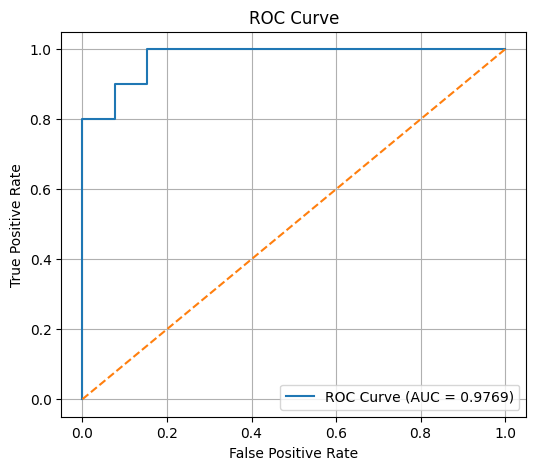


AUC Score: 0.9769230769230769


In [66]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

from sklearn.metrics import roc_curve, auc

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        # ✅ get probabilities
        probs = F.softmax(outputs, dim=1)[:, 1]

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())


all_labels_np = np.array(all_labels)
all_probs_np = np.array(all_probs)

fpr, tpr, thresholds = roc_curve(all_labels_np, all_probs_np)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

print("\nAUC Score:", roc_auc)

In [67]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Accuracy
accuracy = accuracy_score(all_labels, all_preds)

# Classification report
report = classification_report(
    all_labels,
    all_preds,
    target_names=["Non-Depression", "Depression"],
    output_dict=True
)


results_df = pd.DataFrame({
    "Model": ["ResNet18"],
    "Accuracy": [accuracy],
    "Precision (Weighted)": [report["weighted avg"]["precision"]],
    "Recall (Weighted)": [report["weighted avg"]["recall"]],
    "F1 Score (Weighted)": [report["weighted avg"]["f1-score"]],
})



class_results_df = pd.DataFrame(report).transpose()

print("\n===== CLASS-WISE RESULTS =====")
display(class_results_df)


===== CLASS-WISE RESULTS =====


,precision,recall,f1-score,support
Non-Depression,0.916667,0.846154,0.880000,13.000000
Depression,0.818182,0.900000,0.857143,10.000000
accuracy,0.869565,0.869565,0.869565,0.869565
macro avg,0.867424,0.873077,0.868571,23.000000
weighted avg,0.873847,0.869565,0.870062,23.000000


### Inference

The ResNet image model shows **good performance (~87%)** but lower than text models.

### Insight  
- Correct predictions: **20 / 23** (high accuracy for small data)  
- Slight errors in both classes → fairly balanced  
- Performs better on **Non-Depression (precision)**  
- Better recall for **Depression class**


# FUSION ANALYSIS

## TEXT FEATURE EXTRACTOR

### Context

This code creates a **feature extractor from your trained RoBERTa + BiGRU model**.

### What it does

- Takes the **trained RoBERTa + BiGRU model**
- Passes input text through:
  - RoBERTa → embeddings  
  - BiGRU → sequence features  
- Extracts the **last hidden state** (important features)
- Uses a **linear layer (projection)** to refine features  

---

### Output

* Returns a **fixed-size feature vector (256-dim)** instead of class predictions

In [91]:
# MULTIMODAL FUSION - TEXT FEATURE EXTRACTOR

class RoBERTa_BiGRU_Feature(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        
        self.roberta = trained_model.roberta
        self.bigru = trained_model.bigru
        
        # BiGRU output is 256 (hidden_dim*2)
        self.projection = nn.Linear(256, 256)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state
        gru_output, _ = self.bigru(sequence_output)

        last_hidden = gru_output[:, -1, :]   # (batch, 256)
        features = self.projection(last_hidden)

        return features

In [92]:
text_feature_model = RoBERTa_BiGRU_Feature(roberta_model).to(device)

# Freeze RoBERTa backbone
for param in text_feature_model.roberta.parameters():
    param.requires_grad = False

## IMAGE FEATURE EXTRACTOR

### Context:

This code:

- Takes a **trained ResNet18 model**
- Removes the **last classification layer**
- Extracts **important image features (512-dim)**
- Converts them into **256-dim features**

---

### Purpose

* Turns images into **feature vectors**  
* Used for **combining with text in multimodal model**

In [68]:
# MULTIMODAL FUSION - IMAGE FEATURE EXTRACTOR

class ResNet18_Feature(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        
        # Remove final classification layer
        self.features = nn.Sequential(*list(trained_model.children())[:-1])
        
        # ResNet18 last feature size = 512
        self.projection = nn.Linear(512, 256)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)   # (batch, 512)
        x = self.projection(x)     # (batch, 256)
        return x

In [69]:
image_feature_model = ResNet18_Feature(model).to(device)

# Freeze backbone
for param in image_feature_model.features.parameters():
    param.requires_grad = False

In [70]:
!pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00


In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import copy
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoTokenizer
from torch.optim import AdamW

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

import open_clip

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [72]:
import torch
import open_clip
from PIL import Image
from tqdm import tqdm
import numpy as np

### Context

- Loads a **CLIP model** (can understand both image and text)  
- Uses a **pre-trained model** (already trained by OpenAI)  
- Moves the model to **GPU** → faster processing  
- Sets model to **evaluation mode** → only for testing, not training  
- Loads a **tokenizer** → converts text into numbers  

### Purpose

* Helps the model understand **images and text together**

In [73]:
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)

clip_model = clip_model.to(device)
clip_model.eval()

tokenizer_clip = open_clip.get_tokenizer("ViT-B-32")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [74]:
# CREATING TEXT DATAFRAMES

text_train_df = pd.DataFrame({
    "text": train_texts,
    "label": train_labels
})

text_val_df = pd.DataFrame({
    "text": val_texts,
    "label": val_labels
})

text_test_df = pd.DataFrame({
    "text": test_texts,
    "label": test_labels
})

In [75]:
print(text_train_df.columns)

Index(['text', 'label'], dtype='object')


### Context

- Takes all **text data** from the dataset  
- Processes text in **small batches (64 at a time)**  
- Converts text into numbers using **CLIP tokenizer**  
- Passes text through **CLIP model** to get features  
- Normalizes features (makes values stable)  
- Combines all features into one big tensor  

---

### 🔹 Purpose

* Converts text into **numerical features**  
* These features can be used with **images for multimodal learning**

In [76]:
# BUILD TEXT FEATURES

def build_text_features(text_df):
    
    all_texts = text_df["text"].tolist()
    features_list = []

    with torch.no_grad():
        for i in tqdm(range(0, len(all_texts), 64)):
            batch = all_texts[i:i+64]
            tokens = tokenizer_clip(batch).to(device)

            feats = clip_model.encode_text(tokens)
            feats = feats / feats.norm(dim=-1, keepdim=True)

            features_list.append(feats)

    features = torch.cat(features_list, dim=0)  # (N, D)

    return all_texts, features

### Context

- For each **image**, it finds the **most similar texts**  
- Uses CLIP to:
  - Convert image → features  
  - Compare with all text features  

---

### Step-by-step

- Takes one image  
- Converts it into features using CLIP  
- Compares it with all text features (similarity score)  
- Selects **top 5 most similar texts (Top-K)**  
- Chooses one text **smartly using probability (softmax)**  
- Matches that text to the image  

---

### Output

* Returns a list of **matched texts for each image**

---

### Purpose

* Creates **image-text pairs automatically**  
* Useful for **multimodal learning (image + text together)**  

In [77]:
#  CLIP PAIRING FUNCTION (TOP-K SMART)

def match_images_with_texts(image_df, text_list, text_features, k=5):
    
    matched_texts = []

    text_features = text_features.to(device)

    with torch.no_grad():
        for img_path in tqdm(image_df["image_path"]):

            image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)

            img_feat = clip_model.encode_image(image)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

            sim = img_feat @ text_features.T  # (1, N)

            # 🔥 TOP-K SAMPLING (better than random)
            topk_vals, topk_idx = torch.topk(sim, k=k, dim=1)

            # 🔥 SOFTMAX SAMPLING (SMARTER)
            probs = torch.softmax(topk_vals, dim=1).cpu().numpy().flatten()
            chosen = np.random.choice(k, p=probs)

            selected_idx = topk_idx[0][chosen].item()

            matched_texts.append(text_list[selected_idx])

    return matched_texts

In [78]:
#  BUILDING TEXT FEATURES

train_texts_list, train_text_feats = build_text_features(text_train_df)
val_texts_list, val_text_feats     = build_text_features(text_val_df)
test_texts_list, test_text_feats   = build_text_features(text_test_df)

100%|██████████| 18/18 [00:02<00:00,  8.78it/s]


### Context:

Each dataset for training, testing, and validating contains:
- image path  
- matched text  
- label  

---

### Output

* New **multimodal dataset (image + text + label)**  

---

### Purpose

* Prepares data for **fusion model (image + text together)**

In [79]:
#  TRAIN PAIRING

train_matched = match_images_with_texts(
    image_train_df,
    train_texts_list,
    train_text_feats,
    k=5
)

fusion_train_df = pd.DataFrame({
    "image_path": image_train_df["image_path"].values,
    "text": train_matched,
    "label": image_train_df["label"].values
})


#  VALIDATION PAIRING 

val_matched = match_images_with_texts(
    image_val_df,
    val_texts_list,
    val_text_feats,
    k=5
)

fusion_val_df = pd.DataFrame({
    "image_path": image_val_df["image_path"].values,
    "text": val_matched,
    "label": image_val_df["label"].values
})


#  TEST PAIRING 

test_matched = match_images_with_texts(
    image_test_df,
    test_texts_list,
    test_text_feats,
    k=5
)

fusion_test_df = pd.DataFrame({
    "image_path": image_test_df["image_path"].values,
    "text": test_matched,
    "label": image_test_df["label"].values
})

100%|██████████| 23/23 [00:00<00:00, 98.92it/s] 


### Context:

This dataset:
- Loads **image + text + label** together  
- Applies:
  - Image transformations  
  - Text tokenization  
- Converts everything into **tensors**  

In [88]:
class FusionDataset(Dataset):

    def __init__(self, df, tokenizer, transform, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)

        encoding = self.tokenizer(
            row["text"],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "image": image,
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }

### Context:

This code builds a **multimodal model** that combines **text + image** to make predictions.

---

### Step-by-step

#### 1. Extract features
- Text → from **text encoder (RoBERTa + BiGRU)**  
- Image → from **image encoder (ResNet)**  

* Both become **256-dim vectors**

---

#### 2. Normalize features
- Makes values stable and comparable  

---

#### 3. Modality Dropout (during training)
- Randomly removes text or image (30% chance)  
* Makes model more robust  

---

#### 4. Combine (Fusion)

Different ways to combine text + image:

- **add** → simple addition  
- **concat** → join both vectors  
- **attention** → focus on important parts  
- **concat_attention** → combine both attentions  
- **bilinear** → multiply features  
- **cross_residual** → mix both with residual connections  

---

#### 5. Final step
- Apply dropout  
- Pass through classifier → predicts **2 classes**

---

###  Purpose

* Combines **text + image information**  
* Improves prediction using both modalities together  

In [89]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionFusionModel(nn.Module):

    def __init__(self, text_encoder, image_encoder, fusion_type="attention"):
        super().__init__()

        self.text_encoder = text_encoder
        self.image_encoder = image_encoder
        self.fusion_type = fusion_type

        hidden_dim = 256

        # LayerNorm
        self.text_norm = nn.LayerNorm(hidden_dim)
        self.image_norm = nn.LayerNorm(hidden_dim)

        #  Cross Attention
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=4,
            dropout=0.1,
            batch_first=True
        )

        #  Projection layers
        self.text_proj = nn.Linear(hidden_dim, hidden_dim)
        self.image_proj = nn.Linear(hidden_dim, hidden_dim)

        #  Cross residual
        self.text_to_image = nn.Linear(hidden_dim, hidden_dim)
        self.image_to_text = nn.Linear(hidden_dim, hidden_dim)

        #  FiLM
        self.gamma_layer = nn.Linear(hidden_dim, hidden_dim)
        self.beta_layer = nn.Linear(hidden_dim, hidden_dim)

        #  Final normalization
        self.norm = nn.LayerNorm(hidden_dim)

        #  Classifier
        if fusion_type in ["concat", "concat_attention"]:
            self.classifier = nn.Linear(hidden_dim * 2, 2)
        else:
            self.classifier = nn.Linear(hidden_dim, 2)

        self.dropout = nn.Dropout(0.3)

    def forward(self, image, input_ids, attention_mask):

        
        #  Feature Extraction
        
        text_feat = self.text_encoder(input_ids, attention_mask)  # (B,256)
        image_feat = self.image_encoder(image)                    # (B,256)

        #  Normalize 
        text_feat = self.text_norm(text_feat)
        image_feat = self.image_norm(image_feat)

        #  L2 normalization 
        text_feat = F.normalize(text_feat, dim=1)
        image_feat = F.normalize(image_feat, dim=1)

        
        #  MODALITY DROPOUT
        
        if self.training:
            if torch.rand(1).item() < 0.3:
                text_feat = torch.zeros_like(text_feat)
            if torch.rand(1).item() < 0.3:
                image_feat = torch.zeros_like(image_feat)

        #  BASIC FUSIONS
        
        if self.fusion_type == "add":
            fused = text_feat + image_feat

        elif self.fusion_type == "concat":
            fused = torch.cat([text_feat, image_feat], dim=1)

        #  ATTENTION
        
        elif self.fusion_type == "attention":

            t = text_feat.unsqueeze(1)
            i = image_feat.unsqueeze(1)

            attn_output, _ = self.cross_attention(
                query=t,
                key=i,
                value=i
            )

            fused = attn_output.squeeze(1)
            fused = self.norm(fused)

        #  CONCAT + ATTENTION
        
        elif self.fusion_type == "concat_attention":

            t = text_feat.unsqueeze(1)
            i = image_feat.unsqueeze(1)

            attn_t, _ = self.cross_attention(t, i, i)
            attn_i, _ = self.cross_attention(i, t, t)

            fused = torch.cat([
                attn_t.squeeze(1),
                attn_i.squeeze(1)
            ], dim=1)

        #  BILINEAR
        
        elif self.fusion_type == "bilinear":

            t_proj = self.text_proj(text_feat)
            i_proj = self.image_proj(image_feat)

            fused = t_proj * i_proj
            fused = self.norm(fused)

        #  CROSS RESIDUAL
        
        elif self.fusion_type == "cross_residual":

            image_res = image_feat + self.text_to_image(text_feat)
            text_res  = text_feat + self.image_to_text(image_feat)

            fused = image_res + text_res
            fused = self.norm(fused)

        

        else:
            raise ValueError("Invalid fusion type")

        #  FINAL CLASSIFICATION
        
        fused = self.dropout(fused)

        return self.classifier(fused)

### Context: 

This function:

- Trains a **multimodal model (text + image)**
- Uses:
  - DataLoaders for train, validation, test  
  - Class weights for balance  
  - Optimizer + scheduler  
  - Mixed precision for faster training  

---

###  During Training

- Trains model on batches  
- Calculates loss and updates weights  
- Evaluates on validation data each epoch  
- Saves **best model (based on F1 score)**  
- Stops early if no improvement  

---

###  After Training

- Loads best model  
- Tests on test data  
- Calculates:
  - Accuracy  
  - Precision  
  - Recall  
  - F1  
  - AUC (ROC score)

In [90]:
def train_fusion_model(fusion_type="attention", epochs=10, batch_size=16, lr=1e-4):

    print(f"\n Training Fusion Model ({fusion_type})")

    tokenizer = AutoTokenizer.from_pretrained("roberta-base")

    train_loader = DataLoader(
        FusionDataset(fusion_train_df, tokenizer, train_transform),
        batch_size=batch_size, shuffle=True
    )

    val_loader = DataLoader(
        FusionDataset(fusion_val_df, tokenizer, val_transform),
        batch_size=batch_size
    )

    test_loader = DataLoader(
        FusionDataset(fusion_test_df, tokenizer, val_transform),
        batch_size=batch_size
    )

    model = AttentionFusionModel(
        text_feature_model,
        image_feature_model,
        fusion_type=fusion_type
    ).to(device)

    # CLASS WEIGHTS
    
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(fusion_train_df["label"]),
        y=fusion_train_df["label"]
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    #  LR Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

    #  Mixed precision
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_f1 = 0
    best_weights = None
    patience = 4
    trigger = 0

    for epoch in range(epochs):

        #  TRAIN 
        model.train()
        train_loss = 0
        train_preds, train_labels = [], []

        for batch in train_loader:

            optimizer.zero_grad()

            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(images, input_ids, attention_mask)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)

        #  VALIDATION 
        
        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:

                images = batch["image"].to(device)
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["label"].to(device)

                outputs = model(images, input_ids, attention_mask)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        precision, recall, val_f1, _ = precision_recall_fscore_support(
            val_labels, val_preds, average="weighted"
        )

        #  Scheduler step
        scheduler.step(val_f1)

        print(
            f"Epoch {epoch+1} | "
            f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
        )

        #  EARLY STOPPING
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_weights = copy.deepcopy(model.state_dict())
            trigger = 0
        else:
            trigger += 1
            if trigger >= patience:
                print(" Early stopping triggered")
                break

    #  LOAD BEST 
    
    model.load_state_dict(best_weights)

    #  TEST 
    
    model.eval()
    preds, labels_all, probs_all = [], [], []

    with torch.no_grad():
        for batch in test_loader:

            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(images, input_ids, attention_mask)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            pred = torch.argmax(outputs, dim=1)

            preds.extend(pred.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs_all.extend(probs.cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_all, preds, average="weighted"
    )

    # ROC
    
    fpr, tpr, _ = roc_curve(labels_all, probs_all)
    roc_auc = auc(fpr, tpr)

    return pd.DataFrame([{
        "Model": f"Text + Image ({fusion_type})",
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": roc_auc
    }]), (labels_all, probs_all)

In [93]:
all_results = []
all_roc_data = {}

fusion_list = [
    "add",
    "concat",
    "attention",
    "concat_attention",
    "bilinear",
    "cross_residual",

]

for fusion in fusion_list:

    print(f"\n{'='*50}")
    print(f"🔥 Running Fusion: {fusion}")
    print(f"{'='*50}")

    result_df, roc_data = train_fusion_model(fusion)

    # store results
    all_results.append(result_df)

    # store ROC safely
    y_true, y_prob = roc_data
    all_roc_data[fusion] = (np.array(y_true), np.array(y_prob))

print("\n✅ ALL FUSION MODELS TRAINED")


🔥 Running Fusion: add

 Training Fusion Model (add)


/tmp/ipykernel_55/2275563310.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_55/2275563310.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 1 | Train Loss: 0.6748 | Train Acc: 0.6159 | Val Loss: 0.6082 | Val Acc: 0.7660 | Val F1: 0.7649


/tmp/ipykernel_55/2275563310.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 2 | Train Loss: 0.6317 | Train Acc: 0.6585 | Val Loss: 0.5579 | Val Acc: 0.7660 | Val F1: 0.7649


...

Epoch 3 | Train Loss: 0.3113 | Train Acc: 0.8516 | Val Loss: 0.1399 | Val Acc: 0.9574 | Val F1: 0.9573


/tmp/ipykernel_55/2275563310.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 4 | Train Loss: 0.2557 | Train Acc: 0.8659 | Val Loss: 0.1513 | Val Acc: 0.9362 | Val F1: 0.9361


/tmp/ipykernel_55/2275563310.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 5 | Train Loss: 0.2639 | Train Acc: 0.8496 | Val Loss: 0.1443 | Val Acc: 0.9362 | Val F1: 0.9361
 Early stopping triggered

✅ ALL FUSION MODELS TRAINED


In [94]:
fusion_results = pd.concat(all_results, ignore_index=True)
fusion_results = fusion_results.sort_values("F1", ascending=False)
fusion_results

,Model,Accuracy,Precision,Recall,F1,AUC
3,Text + Image (concat_attention),0.956522,0.960474,0.956522,0.956687,0.984615
4,Text + Image (bilinear),0.869565,0.873847,0.869565,0.870062,0.976923
2,Text + Image (attention),0.869565,0.870945,0.869565,0.868548,0.946154
0,Text + Image (add),0.826087,0.839921,0.826087,0.826746,0.976923
1,Text + Image (concat),0.826087,0.839921,0.826087,0.826746,0.969231
5,Text + Image (cross_residual),0.826087,0.839921,0.826087,0.826746,0.946154


### Final Conclusion

- **Best Model:**  **Text + Image (concat_attention)** → ~95.65%  
- Other fusion methods perform **significantly lower (~82–87%)**

---

###  Insight  
- Combining **text + image improves performance**  
- **Attention-based fusion works best**  
- Simple methods (add, concat) are weaker  
- Bilinear and basic attention are moderate  

---

###  Final Takeaway  

* **Concat + Attention is the most effective fusion strategy**  
* Multimodal learning clearly **boosts performance compared to single modality**  

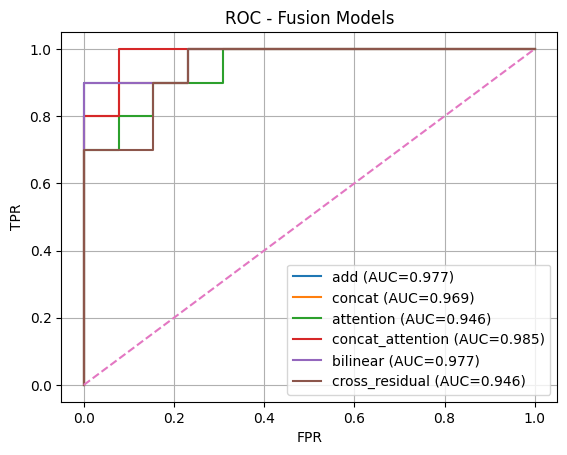

In [95]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure()

for fusion, (y_true, y_prob) in all_roc_data.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{fusion} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC - Fusion Models")
plt.legend()
plt.grid()

plt.show()

###  ROC Curve Conclusion (Fusion Models)

- **Best Model:**  **concat_attention (AUC = 0.985)**  
- **Strong Models:**  
  - add (0.977)  
  - bilinear (0.977)  

- **Moderate:**  
  - concat (0.969)  

- **Lower:**  
  - attention (0.946)  
  - cross_residual (0.946)  

---

###  Insight  
- All models perform **very well (AUC > 0.94)**  
- **concat + attention clearly dominates**  
- Simple attention alone is weaker than combined methods  

---

### Final Takeaway  

* **Concat + Attention is the most powerful fusion strategy**  
* Multimodal model shows **excellent class separation ability**

In [96]:
import pandas as pd

# Get Support (number of test samples)

text_support = len(test_loader.dataset)
image_support = len(all_labels)   
fusion_support = len(image_test_df)

# Create Unimodal Results

unimodal_results = pd.DataFrame([

    #  TEXT MODELS 
    {
        "Model Name": "RoBERTa + BiGRU",
        "Fusion Type": "Text Only",
        "Precision": roberta_prec,
        "Recall": roberta_rec,
        "F1 Score": roberta_f1,
        "Support": text_support
    },
    {
        "Model Name": "BERT + BiGRU",
        "Fusion Type": "Text Only",
        "Precision": bert_prec,
        "Recall": bert_rec,
        "F1 Score": bert_f1,
        "Support": text_support
    },
    {
        "Model Name": "DistilBERT + BiGRU",
        "Fusion Type": "Text Only",
        "Precision": distil_prec,
        "Recall": distil_rec,
        "F1 Score": distil_f1,
        "Support": text_support
    },

    #  IMAGE MODEL 
    {
        "Model Name": "ResNet Image Model",
        "Fusion Type": "Image Only",
        "Precision": precision,   
        "Recall": recall,
        "F1 Score": f1,
        "Support": image_support
    }
])

# Preparing Fusion Results

fusion_results_formatted = fusion_results.copy()

fusion_results_formatted["Fusion Type"] = fusion_results_formatted["Model"].apply(
    lambda x: x.split("(")[-1].replace(")", "")
)

fusion_results_formatted["Support"] = fusion_support

fusion_results_formatted = fusion_results_formatted.rename(columns={
    "Model": "Model Name",
    "F1": "F1 Score"
})

fusion_results_formatted = fusion_results_formatted[
    ["Model Name", "Fusion Type", "Precision", "Recall", "F1 Score", "Support"]
]

# Combining All Results

final_models_df = pd.concat(
    [unimodal_results, fusion_results_formatted],
    ignore_index=True
)

# Sorting by Best Model (F1 Score)

final_models_df = final_models_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("\n===== FINAL MODEL COMPARISON =====")
display(final_models_df)


===== FINAL MODEL COMPARISON =====


,Model Name,Fusion Type,Precision,Recall,F1 Score,Support
0,BERT + BiGRU,Text Only,0.985261,0.985192,0.985190,23
1,DistilBERT + BiGRU,Text Only,0.985517,0.985192,0.985186,23
2,RoBERTa + BiGRU,Text Only,0.984463,0.984321,0.984317,23
3,Text + Image (concat_attention),concat_attention,0.960474,0.956522,0.956687,23
4,ResNet Image Model,Image Only,0.873847,0.869565,0.870062,23
5,Text + Image (bilinear),bilinear,0.873847,0.869565,0.870062,23
6,Text + Image (attention),attention,0.870945,0.869565,0.868548,23
7,Text + Image (add),add,0.839921,0.826087,0.826746,23
8,Text + Image (concat),concat,0.839921,0.826087,0.826746,23
9,Text + Image (cross_residual),cross_residual,0.839921,0.826087,0.826746,23


### Final Overall Conclusion

 #### **Best Models:**  
  - DistilBERT + BiGRU  
  - BERT + BiGRU  
  - ~98.5% F1 (highest performance)

####  **Multimodal Best:**  
  - Text + Image (concat_attention) → ~95.7%

  #### **Image Only:**  
  - ResNet → ~87%

---

###  Insights  
- **Text models outperform all others**  
- Multimodal improves over image-only but **does not beat text-only**  
- Best fusion method = **concat + attention**  
- Image-only model has **limited performance**

---

###  Final Takeaway  

* **Text data is most powerful for this task**  
* Multimodal helps, but only when fused properly  
* **Best choice overall: DistilBERT / BERT models**